In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import joblib

In [27]:
df=pd.read_csv( "../data/processed/hyderabad_cleaned.csv")
df.shape

(2276, 44)

In [28]:
df["log_price"] = np.log1p(df["price"])

In [29]:
X = df.drop(
    columns=["price", "log_price"]
)

y = df["log_price"]

In [30]:
numerical_features = X.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features = X.select_dtypes(
    exclude=np.number
).columns.tolist()
print(numerical_features)
print(categorical_features)

['area', 'no_of_bedrooms', 'resale', 'maintenancestaff', 'gymnasium', 'swimmingpool', 'landscapedgardens', 'joggingtrack', 'rainwaterharvesting', 'indoorgames', 'shoppingmall', 'intercom', 'sportsfacility', 'atm', 'clubhouse', 'school', '24x7security', 'powerbackup', 'carparking', 'staffquarter', 'cafeteria', 'multipurposeroom', 'hospital', 'washingmachine', 'gasconnection', 'ac', 'wifi', "children'splayarea", 'liftavailable', 'bed', 'vaastucompliant', 'microwave', 'golfcourse', 'tv', 'diningtable', 'sofa', 'wardrobe', 'refrigerator', 'latitude', 'longitude']
['location', 'city']


In [31]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [32]:
numeric_transformer=Pipeline([
    (
        "imputer",
        SimpleImputer(strategy='median')
    ),
    (
        'scaler',
        StandardScaler()
    )
])

In [33]:
categorical_transformer=Pipeline([
    (
        "imputer",
        SimpleImputer(strategy='most_frequent')
    ),
    (
        "encoder",
        OneHotEncoder(
            handle_unknown='ignore'
        )
    )
])

In [34]:
preprocessor=ColumnTransformer([
    (
        'num',
        numeric_transformer,
        numerical_features

    ),
    (
        'cat',
        categorical_transformer,
        categorical_features
    )
])

In [35]:
lr_pipline=Pipeline([
    (
        'preprocessor',
        preprocessor
    ),
    (
        'model',
        LinearRegression()
    )
])

In [36]:
ridge_pipline=Pipeline([
    (
        'preprocessor',
        preprocessor
    ),
    (
        'model',
        Ridge(alpha=1.0)
    )
])

In [37]:
lasso_pipline=Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        'model',
        Lasso(alpha=0.01)
    )
])

In [38]:
lr_pipline.fit(X_train,y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [39]:
ridge_pipline.fit(X_train,y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [40]:
lasso_pipline.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [41]:
def evaluate_model(model, X_test, y_test):

    preds = model.predict(X_test)

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            preds
        )
    )

    mae = mean_absolute_error(
        y_test,
        preds
    )

    r2 = r2_score(
        y_test,
        preds
    )

    return {
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
        "predictions": preds
    }

In [42]:
lr_results=evaluate_model(
    lr_pipline,
    X_test,
    y_test
)

In [43]:
ridge_results=evaluate_model(
    ridge_pipline,
    X_test,
    y_test
)

In [44]:
lasso_results=evaluate_model(
    lasso_pipline,
    X_test,
    y_test
)

In [45]:
results_df = pd.DataFrame({

    "Model": [
        "Linear Regression",
        "Ridge",
        "Lasso"
    ],

    "RMSE": [
        lr_results["RMSE"],
        ridge_results["RMSE"],
        lasso_results["RMSE"]
    ],

    "MAE": [
        lr_results["MAE"],
        ridge_results["MAE"],
        lasso_results["MAE"]
    ],

    "R2": [
        lr_results["R2"],
        ridge_results["R2"],
        lasso_results["R2"]
    ]
})

results_df

,Model,RMSE,MAE,R2
0,Linear Regression,0.221899,0.154701,0.889289
1,Ridge,0.216861,0.152987,0.894259
2,Lasso,0.281162,0.215089,0.822256


In [46]:
results_df.to_csv(
    "../reports/linear_model_results.csv",
    index=False
)

In [47]:
residuals = (
    y_test -
    lr_results["predictions"]
)

Text(0.5, 1.0, 'Residual Plot')

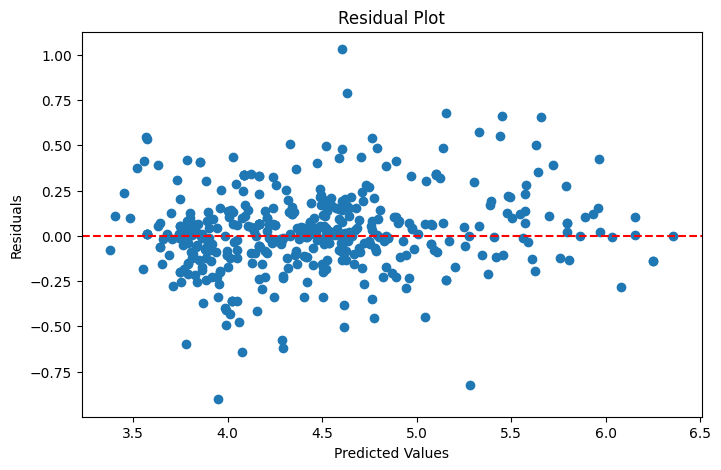

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(
    lr_results["predictions"],
    residuals
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

plt.title("Residual Plot")
plt.savefig(
    "../images/residual_plot.png",
    bbox_inches="tight"
)

plt.show()

Text(0.5, 1.0, 'Actual vs Predicted')

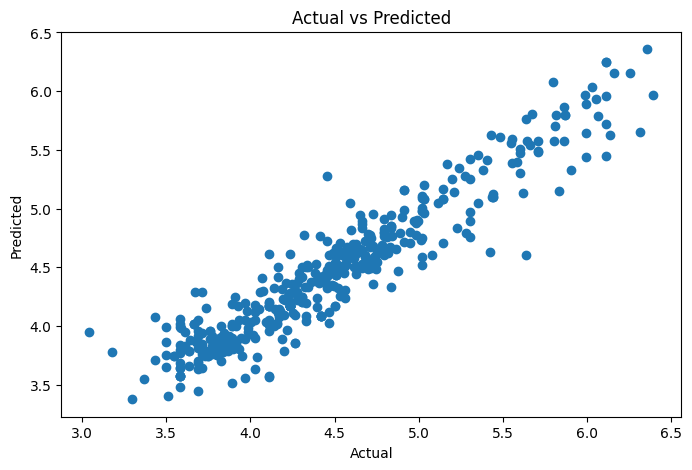

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(
    y_test,
    lr_results["predictions"]
)

plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.title("Actual vs Predicted")
plt.savefig(
    "../images/actual_vs_predicted.png",
    bbox_inches="tight"
)

plt.show()

In [52]:
model = lr_pipline.named_steps["model"]

In [53]:
encoded_features = list(
    lr_pipline.named_steps[
        "preprocessor"
    ]
    .named_transformers_[
        "cat"
    ]
    .named_steps[
        "encoder"
    ]
    .get_feature_names_out(
        categorical_features
    )
)

In [54]:
all_features = (
    numerical_features +
    encoded_features
)

In [55]:
coef_df = pd.DataFrame({
    "Feature": all_features,
    "Coefficient": model.coef_
})

In [56]:
coef_df.sort_values(
    by="Coefficient",
    ascending=False
).head(15)

,Feature,Coefficient
189,location_Saket,1.220415
66,location_Banjara Hills Road Number 12,0.851469
65,location_Banjara Hills,0.649600
79,location_Chikkadapally,0.646618
214,location_Vidyanagar Adikmet,0.580731
109,location_Jubilee Hills,0.579967
68,location_Basheer Bagh,0.549228
84,location_Domalguda Road,0.547357
159,location_Nandagiri Hills,0.523316
83,location_Domalguda,0.506621


In [57]:
coef_df.sort_values(
    by="Coefficient",
    ascending=True
).head(15)

,Feature,Coefficient
111,location_KTR Colony,-0.627872
107,location_Isnapur,-0.614572
173,location_Pocharam,-0.548637
73,location_Bollaram,-0.538946
99,location_Hakimpet,-0.533175
56,location_BK Guda Internal Road,-0.517981
167,location_Old Nallakunta,-0.497872
225,location_muthangi,-0.484933
170,location_Patancheru,-0.459727
148,location_Miyapur HMT Swarnapuri Colony,-0.434191


In [58]:
coef_df.to_csv(
    "../reports/linear_model_coefficients.csv",
    index=False
)

In [59]:
joblib.dump(
    lr_pipline,
    "../models/linear_regression.pkl"
)

['../models/linear_regression.pkl']

In [60]:
joblib.dump(
    ridge_pipline,
    "../models/ridge_regression.pkl"
)

['../models/ridge_regression.pkl']

In [61]:
joblib.dump(
    lasso_pipline,
    "../models/lasso_regression.pkl"
)

['../models/lasso_regression.pkl']

# Hour 2 Conclusions

1. Built preprocessing pipeline using sklearn Pipeline and ColumnTransformer.
2. Applied scaling to numerical features and encoding to categorical features.
3. Trained Linear Regression, Ridge, and Lasso models.
4. Ridge slightly improved generalization through regularization.
5. Residual analysis indicated remaining nonlinear relationships.
6. Location and area-related features strongly influenced predictions.
7. Models significantly outperformed the baseline estimator.